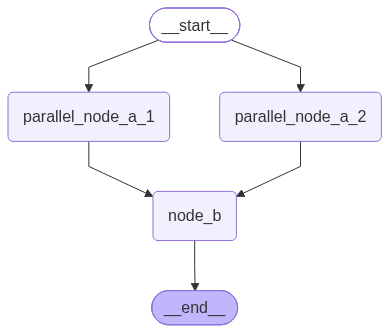

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	parallel_node_a_1(parallel_node_a_1)
	parallel_node_a_2(parallel_node_a_2)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> parallel_node_a_1;
	__start__ --> parallel_node_a_2;
	parallel_node_a_1 --> node_b;
	parallel_node_a_2 --> node_b;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

{'type': 'debug', 'ns': (), 'data': {'step': -1, 'timestamp': '2026-08-15T06:21:32.994441+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '123', 'checkpoint_id': '1f198718-f68a-6c18-bfff-f0c829e6c24a'}}, 'parent_config': None, 'values': {}, 'metadata': {'source': 'input', 'step': -1, 'parents': {}}, 'next': ['__start__'], 'tasks': [{'id': 'ee6896ec-8d74-4418-e194-7393116f653f', 'name': '__start__', 'interrupts': (), 'state': None}]}}}
{'type': 'debug', 'ns': (

In [1]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,END,START
from langgraph.types import interrupt, Command


#1. 声明状态
class OverAllState(TypedDict):
    initial_state:str
    parallel_node_a_1:str
    parallel_node_a_2:str
    node_b_output:str

#2. 声明节点
def parallel_node_a_1(state:OverAllState) -> OverAllState:
    return {
        "parallel_node_a_1":"并行节点A-1的输出"
    }

def parallel_node_a_2(state:OverAllState) -> OverAllState:
    return {
        "parallel_node_a_2":"并行节点A-2的输出"
    }

def node_b(state:OverAllState) -> OverAllState:
    # interrupt("hello")
    return {
        "node_b_output":"节点B的输出"
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("parallel_node_a_1",parallel_node_a_1)
builder.add_node("parallel_node_a_2",parallel_node_a_2)
builder.add_node("node_b",node_b)
builder.add_edge(START,"parallel_node_a_1")
builder.add_edge(START,"parallel_node_a_2")
builder.add_edge(["parallel_node_a_1","parallel_node_a_2"],"node_b")
builder.add_edge("node_b",END)

#4. 添加检查点后端
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer= checkpointer)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

config = {"configurable":{"thread_id":"123"}}
for chunk in graph.stream(
    {"initial_state":"初始状态"},
    config=config,
    stream_mode=["debug"],
    version="v2"
    # stream_mode=["tasks"]
    # stream_mode=["checkpoints"]
):
    print(chunk)


In [15]:
from langgraph.types import interrupt, Command
print("*" * 50 )
for chunk in graph.stream(
    Command(resume=""),
    config=config,
    stream_mode=["checkpoints"]
):
    print(chunk)


**************************************************
('checkpoints', {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '123', 'checkpoint_id': '1f17e974-45ad-6c53-8002-0aa51318c1f4'}}, 'parent_config': {'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17e974-45ac-6e66-8001-29ad775569b6'}}, 'values': {'initial_state': '初始状态', 'parallel_node_a_1': '并行节点A-1的输出', 'parallel_node_a_2': '并行节点A-2的输出', 'node_b_output': '节点B的输出'}, 'metadata': {'source': 'loop', 'step': 2, 'parents': {}}, 'next': [], 'tasks': []})


In [16]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'initial_state': '初始状态', 'parallel_node_a_1': '并行节点A-1的输出', 'parallel_node_a_2': '并行节点A-2的输出', 'node_b_output': '节点B的输出'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17e974-45ad-6c53-8002-0aa51318c1f4'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-13T08:45:57.716278+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17e974-45ac-6e66-8001-29ad775569b6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'initial_state': '初始状态', 'parallel_node_a_1': '并行节点A-1的输出', 'parallel_node_a_2': '并行节点A-2的输出'}, next=('node_b',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17e974-45ac-6e66-8001-29ad775569b6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-13T08:45:57.715917+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17e